In [5]:
SIM_FILE = '/datascope/subaru/user/swei20/data/bosz50000/z1/mag205_225_lowT_1M/train_200k_0/dataset.h5'

N = 100

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

In [3]:
# Load the pandas DataFrame from the HDF5 file stored in /dataset/params/table
with h5py.File(SIM_FILE, 'r') as f:
    params = pd.read_hdf(SIM_FILE, key='dataset/params')

params.shape

(200000, 35)

In [4]:
for c in params.columns:
    print(c, params[c].dtype, params[c].nunique())

id int64 200000
redshift float64 200000
redshift_err float64 1
exp_count int64 1
exp_time float64 1
seeing float64 200000
ext float64 0
target_zenith_angle float64 200000
target_field_angle float64 200000
moon_zenith_angle float64 200000
moon_target_angle float64 200000
moon_phase float64 1
snr float64 200000
mag float64 200000
fiberid float64 0
cont_fit float64 0
random_seed float64 0
Fe_H float64 0
Fe_H_err float64 0
M_H float64 40185
M_H_err float64 0
a_M float64 40104
a_M_err float64 0
C_M float64 40021
C_M_err float64 0
O_M float64 0
O_M_err float64 0
T_eff float64 40241
T_eff_err float64 0
log_g float64 39492
log_g_err float64 0
N_He float64 0
v_turb float64 0
L_H float64 0
interp_param object 5


In [6]:
# Load the selected spectra from the HDF5 file
with h5py.File(SIM_FILE, 'r') as f:
    wave = f['spectrumdataset/wave'][:]
    flux = f['dataset/arrays/flux/value'][:N, :]
    flux_err = f['dataset/arrays/error/value'][:N, :]

wave.shape, flux.shape, flux_err.shape

((4096,), (100, 4096), (100, 4096))

CL 7565.0 7585.0
CR 7705.0 7725.0
Line 7590.0 7700.0


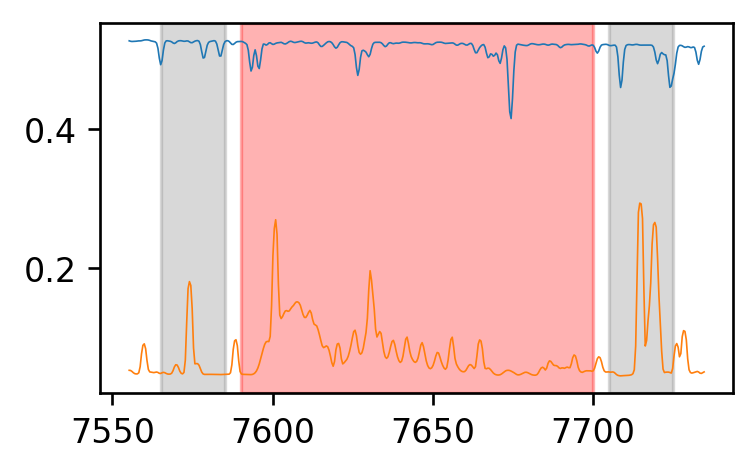

In [22]:
i = 8

# A-band
lo, hi = 7590.0, 7700.0
line_center_a = (lo + hi) / 2.0
line_halfwidth_a = (hi - lo) / 2.0
cont_inner_a = (hi - lo) / 2.0 + 5.0
cont_outer_a = (hi - lo) / 2.0 + 25.0

line_low, line_high = line_center_a - line_halfwidth_a, line_center_a + line_halfwidth_a
cont_left = (wave >= line_center_a - cont_outer_a) & (wave <= line_center_a - cont_inner_a)
cont_right = (wave >= line_center_a + cont_inner_a) & (wave <= line_center_a + cont_outer_a)
line_mask = (wave >= line_low) & (wave <= line_high)
cont_mask = cont_left | cont_right

m = (wave >= line_center_a - cont_outer_a - 10) & (wave <= line_center_a + cont_outer_a + 10)



fig, ax = plt.subplots(figsize=(3.4, 2), dpi=240)
ax.plot(wave[m], flux[i, :][m], lw=0.5)
ax.plot(wave[m], flux_err[i, :][m], lw=0.5)

# Draw rectangle over the continuum regions
ax.axvspan(line_center_a - cont_outer_a, line_center_a - cont_inner_a, color='gray', alpha=0.3)
ax.axvspan(line_center_a + cont_inner_a, line_center_a + cont_outer_a, color='gray', alpha=0.3)

# Draw rectangle over the line region
ax.axvspan(line_low, line_high, color='red', alpha=0.3)

print('CL', line_center_a - cont_outer_a, line_center_a - cont_inner_a)
print('CR', line_center_a + cont_inner_a, line_center_a + cont_outer_a)
print('Line', line_low, line_high)
